# Phân tích spam và seeding cho hệ thống đánh giá thương mại điện tử

**Dự án:** Multimodal Review Analytics Dashboard  
**Đầu vào:** File `scraping_agent/data/all_reviews.csv` chứa các đánh giá đã được nhóm cào từ Tiki, Lazada, Thế Giới Di Động.  
**Đầu ra:** File `data/processed/reviews_flagged.csv` với 1 cột mới `is_spam` (0 = sạch, 1 = spam).

## Mục tiêu của notebook


1. **Tiền xử lý văn bản** — chuẩn hóa unicode, làm sạch HTML/URL/mention/hashtag, đo tỉ lệ từ vựng thay đổi qua từng bước.
2. **Áp dụng bộ luật rule-based** — 17 luật được nhóm theo 4 trục: cấu trúc văn bản, mẫu khuôn, đặc thù sàn TMĐT, bất thường rating-text. Cộng thêm phát hiện trùng lặp seeding bằng TF-IDF + Cosine Similarity.
3. **Phân tích khám phá EDA** — thống kê mô tả, phân tích phân bố nhãn, phân tích mối quan hệ giữa các thuộc tính, phân tích phân phối Zipf, word cloud, type-token ratio, kiểm định Mann-Whitney U, vector hóa và t-SNE 2D.

## Bộ luật 

| Luật | Lý do  |
|------|-------------|
| Bình luận nhận xu | Shopee và Tiki có chương trình thưởng coin, nhiều người gõ bừa cho đủ ký tự |
| Chứa thông tin liên hệ | Sđt / Zalo / FB là chiêu chuyển hướng giao dịch ra ngoài sàn |
| Chứa link bên ngoài | Review thật hầu như không có URL |
| Quảng cáo shop đối thủ | Bắt các review kiểu "qua bên kia rẻ hơn" |
| Mã giảm giá rác | Bắt các review chèn voucher / promo code lung tung |
| Lặp từ liên tục | Bắt kiểu spam câu chữ "tốt tốt tốt tốt tốt" |
| Quá nhiều ký tự đặc biệt | Bắt kiểu spam ký hiệu loạn xạ |
| Quá nhiều chữ in hoa | Bắt kiểu hét lên / quảng cáo |
| Chỉ số và dấu câu | Bắt review không có chữ cái |

## 1. Chuẩn bị môi trường

Nạp các thư viện cần thiết và cấu hình hiển thị tiếng Việt cho biểu đồ. Các tham số chính được đặt ở đây để xuyên suốt hiển thị nhất quán.

In [46]:
# Fix encoding cho console Windows nếu cần
import sys
if hasattr(sys.stdout, "reconfigure"):
    sys.stdout.reconfigure(encoding="utf-8")

from pathlib import Path
from collections import Counter
import warnings
warnings.filterwarnings("ignore")

# Thêm thư mục gốc dự án vào path để import được module ai_engine
ROOT = Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from IPython.display import display, Markdown
from scipy import stats as scipy_stats

# Cấu hình font hỗ trợ tiếng Việt cho matplotlib
matplotlib.rcParams["font.family"] = ["Segoe UI", "Arial", "DejaVu Sans", "sans-serif"]
matplotlib.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 130

# Bộ màu chủ đạo dùng xuyên suốt notebook
COLOR_CLEAN = "#27ae60"      # Xanh lá - đại diện sạch
COLOR_SPAM = "#e74c3c"       # Đỏ - đại diện spam
COLOR_NEUTRAL = "#3498db"    # Xanh dương - thông tin chung
COLOR_HIGHLIGHT = "#f39c12"  # Cam - nhấn mạnh

# Bộ palette đa sắc dùng cho biểu đồ nhiều cột
PALETTE_MULTI = "viridis"
PALETTE_HEAT = "rocket_r"
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.05)

print("Đã nạp xong các thư viện và cấu hình hiển thị")

Đã nạp xong các thư viện và cấu hình hiển thị


In [47]:
# Import các hàm phát hiện spam đã viết trong module spam_filter
from ai_engine.text_processing.spam_filter import (
    detect_spam,
    summarize_spam,
    normalize_pipeline,
    normalize_text,
    remove_emojis,
    count_words,
    count_chars,
    get_emoji_ratio,
    get_special_char_ratio,
    get_uppercase_ratio,
    get_digit_ratio,
    get_type_token_ratio,
)

print("Đã import xong các hàm từ module spam_filter")

Đã import xong các hàm từ module spam_filter


## 2. Nạp dữ liệu thô

Dữ liệu đầu vào là file CSV chứa toàn bộ đánh giá đã được nhóm thu thập từ ba sàn thương mại điện tử. Mỗi dòng là một bình luận với các thông tin cơ bản như nội dung text, số sao, URL sản phẩm, ngày đăng.

In [48]:
# Đường dẫn đến file dữ liệu thô và nơi sẽ lưu kết quả
INPUT_CSV = ROOT / "scraping_agent" / "data" / "all_reviews.csv"
OUTPUT_DIR = ROOT / "data" / "processed"
OUTPUT_CSV = OUTPUT_DIR / "reviews_flagged.csv"

# Đọc với utf-8-sig để xử lý đúng tiếng Việt có dấu (BOM của Windows)
df_raw = pd.read_csv(INPUT_CSV, encoding="utf-8-sig")

print(f"Đã đọc file: {INPUT_CSV.name}")
print(f"Tổng số đánh giá: {len(df_raw):,}")
print(f"Các cột trong file: {list(df_raw.columns)}")

Đã đọc file: all_reviews.csv
Tổng số đánh giá: 7,375
Các cột trong file: ['text', 'rating', 'date', 'image_urls', 'product_url', 'scraped_at']


### 2.1. Xem qua một vài dòng đầu

Trước khi tiền xử lý, ta nhìn nhanh để biết dữ liệu có dạng như thế nào, các cột có giá trị hợp lý không.

In [49]:
display(df_raw.head(5))

,text,rating,date,image_urls,product_url,scraped_at
0,"Nhập khẩu từ Nhật Bản, Dải keo rộng, Được gói ...",5,1 week ago,https://lazvideo.lazcdn.com/psp/20260404/907aa...,https://www.lazada.vn/products/pdp-i246452966-...,2026-04-14T21:23:12.534324
1,tốt.,5,2026-02-11,https://lazvideo.lazcdn.com/psp/20260211/18522...,https://www.lazada.vn/products/pdp-i246452966-...,2026-04-14T21:23:12.534396
2,thay bvs vẫn ok nha,5,2025-11-29,https://lzd-u.slatic.net/cc9434e2de0a4af1be626...,https://www.lazada.vn/products/pdp-i246452966-...,2026-04-14T21:23:12.534408
3,"Dải keo rộng, Chất liệu siêu mềm, Hoàn hảo cho...",5,2025-11-15,https://lazvideo.lazcdn.com/psp/20251115/53218...,https://www.lazada.vn/products/pdp-i246452966-...,2026-04-14T21:23:12.534418
4,tốt êm,5,2025-10-14,https://lazvideo.lazcdn.com/psp/20251014/fd243...,https://www.lazada.vn/products/pdp-i246452966-...,2026-04-14T21:23:12.534423


### 2.2. Thống kê tỉ lệ dữ liệu thiếu

Hai cột cốt lõi cho bộ lọc spam là `text` và `rating`. Nếu thiếu nhiều thì cần xử lý trước khi đưa vào pipeline.

In [50]:
# Đếm số lượng và tỉ lệ giá trị thiếu cho từng cột
missing_count = df_raw.isna().sum()
missing_pct = (df_raw.isna().mean() * 100).round(2)

missing_table = pd.DataFrame({
    "Số lượng thiếu": missing_count,
    "Tỉ lệ thiếu (%)": missing_pct,
})
display(missing_table.style.background_gradient(
    subset=["Tỉ lệ thiếu (%)"], cmap="Reds", vmin=0, vmax=20
))

,Số lượng thiếu,Tỉ lệ thiếu (%)
text,2370,32.140000
rating,0,0.000000
date,58,0.790000
image_urls,3766,51.060000
product_url,0,0.000000
scraped_at,0,0.000000


## 3. Tiền xử lý dữ liệu

### Tại sao cần tiền xử lý?

Dữ liệu cào về từ web luôn có nhiễu: thẻ HTML còn sót, URL người dùng paste vào, ký tự control, tiếng Việt được mã hóa unicode không chuẩn. Nếu áp dụng bộ luật trực tiếp trên dữ liệu thô thì sẽ có nhiều false positive (ví dụ một review thật bị bắt nhầm vì có HTML entity bên trong).

Theo gợi ý của đề bài, ở đây ta áp dụng pipeline chuẩn hóa văn bản hoàn chỉnh và **báo cáo tỉ lệ từ vựng thay đổi** ở mỗi bước, để biết bước nào đang loại bỏ nhiều ký tự nhất.

### 3.1. Loại bỏ các bản ghi không hợp lệ

Trước khi chạy pipeline chuẩn hóa, cần đảm bảo các cột cốt lõi (`text` và `rating`) đều có giá trị hợp lệ.

In [51]:
# Bản sao để không thay đổi dữ liệu gốc
df = df_raw.copy()
n_before = len(df)

# Bỏ các dòng mà cột text rỗng hoặc null (không có nội dung để phân tích)
df = df[df["text"].notna()]
df = df[df["text"].astype(str).str.strip() != ""]

# Bỏ các dòng thiếu rating
df = df[df["rating"].notna()]

# Ép kiểu rating về số nguyên, các giá trị không ép được sẽ bị loại
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
df = df[df["rating"].notna()]
df["rating"] = df["rating"].astype(int)

# Reset index để các bước sau làm việc với index liên tục
df = df.reset_index(drop=True)

n_after = len(df)
print(f"Số đánh giá ban đầu: {n_before:,}")
print(f"Số đánh giá sau làm sạch: {n_after:,}")
print(f"Đã loại bỏ: {n_before - n_after:,} dòng ({(n_before-n_after)/n_before*100:.2f}%)")

Số đánh giá ban đầu: 7,375
Số đánh giá sau làm sạch: 5,005
Đã loại bỏ: 2,370 dòng (32.14%)


### 3.2. Pipeline chuẩn hóa văn bản với báo cáo tỉ lệ thay đổi

Pipeline gồm 6 bước được thiết kế trong module `spam_filter.normalize_pipeline`:

1. **Chuẩn hóa Unicode NFC** — gom các tổ hợp dấu của tiếng Việt về cùng một dạng biểu diễn.
2. **Lowercase** — đồng nhất chữ hoa / chữ thường.
3. **Loại bỏ thẻ HTML** — bắt các thẻ còn sót như `<p>`, `<br>`.
4. **Loại bỏ URL** — bắt cả `https://...` lẫn `www.shopee.vn/...`.
5. **Loại bỏ mention và hashtag** — `@username` và `#tag`.
6. **Chuẩn hóa khoảng trắng** — gộp nhiều space về một space, trim đầu cuối.

Hàm trả về thêm một dictionary thống kê số ký tự bị loại ở mỗi bước, giúp ta hiểu bước nào tác động nhiều nhất.

In [52]:
# Áp dụng pipeline chuẩn hóa cho toàn bộ cột text
print("Đang chạy pipeline chuẩn hóa cho toàn bộ dữ liệu...")
results = df["text"].astype(str).apply(normalize_pipeline)
df["text_clean"] = results.apply(lambda x: x[0])
pipeline_stats = pd.DataFrame(list(results.apply(lambda x: x[1])))

# Tính tổng số ký tự bị loại ở mỗi bước
total_original = pipeline_stats["original_len"].sum()
total_html = pipeline_stats["html_removed"].sum()
total_url = pipeline_stats["url_removed"].sum()
total_mention = pipeline_stats["mention_removed"].sum()
total_final = pipeline_stats["final_len"].sum()

print()
print(f"Tổng số ký tự ban đầu: {total_original:,}")
print(f"Tổng số ký tự sau chuẩn hóa: {total_final:,}")
print(f"Tỉ lệ giảm tổng cộng: {(1 - total_final/total_original)*100:.2f}%")

Đang chạy pipeline chuẩn hóa cho toàn bộ dữ liệu...

Tổng số ký tự ban đầu: 459,039
Tổng số ký tự sau chuẩn hóa: 458,543
Tỉ lệ giảm tổng cộng: 0.11%


### 3.3. Trực quan hóa tác động của từng bước trong pipeline

Biểu đồ dưới đây cho thấy mỗi bước trong pipeline loại bỏ bao nhiêu ký tự khỏi dữ liệu, giúp ta đánh giá xem bước nào đang đóng góp nhiều nhất vào việc làm sạch.

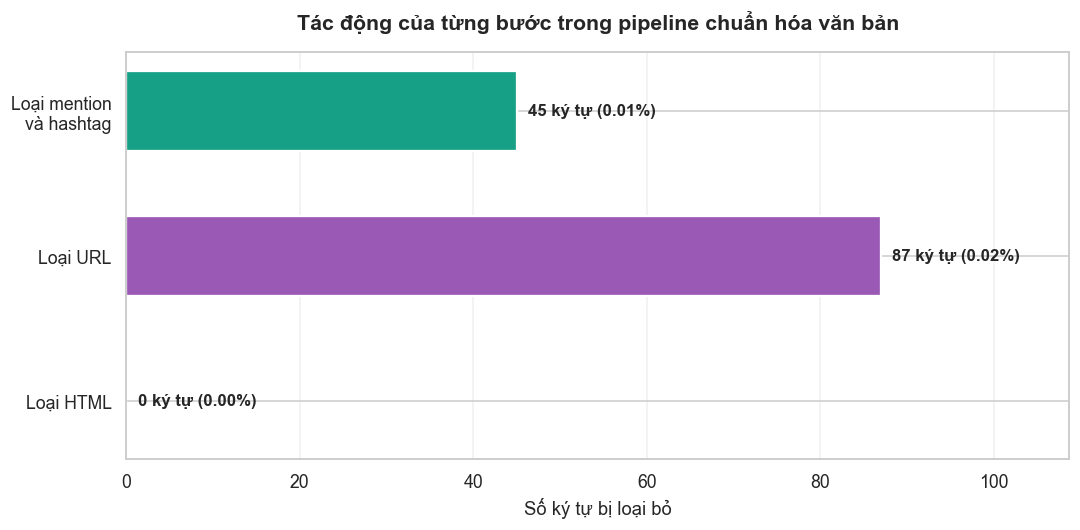

In [53]:
# Vẽ biểu đồ thanh ngang cho 3 bước loại bỏ chính
fig, ax = plt.subplots(figsize=(10, 5))

steps = ["Loại HTML", "Loại URL", "Loại mention\nvà hashtag"]
removed_counts = [total_html, total_url, total_mention]
colors_steps = ["#e67e22", "#9b59b6", "#16a085"]

bars = ax.barh(steps, removed_counts, color=colors_steps,
               edgecolor="white", linewidth=1.5, height=0.55)

for bar, val in zip(bars, removed_counts):
    pct = val / total_original * 100 if total_original > 0 else 0
    ax.text(bar.get_width() + max(removed_counts) * 0.015,
            bar.get_y() + bar.get_height() / 2,
            f"{val:,} ký tự ({pct:.2f}%)",
            va="center", fontsize=11, fontweight="bold")

ax.set_xlabel("Số ký tự bị loại bỏ", fontsize=12)
ax.set_title("Tác động của từng bước trong pipeline chuẩn hóa văn bản",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlim(0, max(removed_counts) * 1.25 if max(removed_counts) > 0 else 1)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### 3.4. Tính các đặc trưng phụ trợ cho EDA

Để phục vụ phân tích sau, ta tính sẵn một loạt đặc trưng từ trường text gốc:

- **Số từ và số ký tự** — thước đo độ dài cơ bản.
- **Tỉ lệ emoji** — review thật cũng có emoji nhưng không quá nhiều.
- **Tỉ lệ ký tự đặc biệt** — phát hiện spam ký hiệu.
- **Tỉ lệ chữ in hoa** — phát hiện kiểu hét lên.
- **Tỉ lệ chữ số** — phát hiện chuỗi số lạ.
- **Type-Token Ratio (TTR)** — đo độ phong phú từ vựng, gợi ý từ đề bài.

In [54]:
# Tính các đặc trưng cơ bản cho từng đánh giá
df["word_count"] = df["text"].apply(count_words)
df["char_count"] = df["text"].astype(str).str.len()
df["emoji_ratio"] = df["text"].apply(get_emoji_ratio)
df["special_char_ratio"] = df["text"].apply(get_special_char_ratio)
df["uppercase_ratio"] = df["text"].apply(get_uppercase_ratio)
df["digit_ratio"] = df["text"].apply(get_digit_ratio)
df["ttr"] = df["text"].apply(get_type_token_ratio)

# Hiển thị thống kê mô tả các đặc trưng vừa tính
feature_cols = ["word_count", "char_count", "emoji_ratio", "special_char_ratio",
                "uppercase_ratio", "digit_ratio", "ttr"]
desc = df[feature_cols].describe().round(3)
display(desc.style.background_gradient(cmap="Blues", axis=1))

,word_count,char_count,emoji_ratio,special_char_ratio,uppercase_ratio,digit_ratio,ttr
count,5005.000000,5005.000000,5005.000000,5005.000000,5005.000000,5005.000000,5005.000000
mean,19.990000,91.716000,0.002000,0.031000,0.031000,0.005000,0.934000
std,17.070000,78.130000,0.038000,0.047000,0.043000,0.020000,0.120000
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7.000000,33.000000,0.000000,0.000000,0.000000,0.000000,0.913000
50%,18.000000,85.000000,0.000000,0.030000,0.031000,0.000000,1.000000
75%,27.000000,124.000000,0.000000,0.042000,0.042000,0.000000,1.000000
max,292.000000,1315.000000,1.000000,1.000000,1.000000,0.500000,1.000000


## 4. Áp dụng bộ lọc spam

Đây là bước quan trọng nhất của notebook. Toàn bộ logic phát hiện đã được đóng gói trong hàm `detect_spam` của module `spam_filter`.

### Hàm này làm gì?

1. **Chấm 16 luật ở mức từng đánh giá riêng lẻ** — mỗi đánh giá được kiểm tra qua từng luật để xác định có dấu hiệu spam nào không.
2. **Tính cosine similarity trên TF-IDF** để tìm các cụm đánh giá trùng lặp (seeding hàng loạt).
3. **Trả về dataframe** được bổ sung đúng một cột `is_spam` (0 nếu sạch, 1 nếu nghi spam).

### Tại sao chọn ngưỡng 0.85 cho cosine similarity?

Đây là ngưỡng cân bằng giữa precision và recall:
- Ngưỡng quá cao (0.95) sẽ bỏ sót nhiều seeding chỉ đổi vài từ.
- Ngưỡng quá thấp (0.70) sẽ bắt nhầm các review thật cùng chủ đề.
- Ngưỡng 0.85 thường được dùng trong các nghiên cứu về phát hiện văn bản trùng lặp.

In [55]:
# Chạy bộ lọc spam trên toàn bộ dữ liệu đã tiền xử lý
df_flagged = detect_spam(df, dup_threshold=0.85)
print()
print("Đã hoàn tất gán cờ is_spam cho toàn bộ dataframe")

[spam_filter] Đang chấm các luật ở mức từng review...
[spam_filter] Đang tính cosine similarity để tìm review trùng lặp...
[spam_filter] Hoàn tất. Tổng review: 5,005, Nghi spam: 2,394

Đã hoàn tất gán cờ is_spam cho toàn bộ dataframe


### 4.1. Kiểm tra kết quả nhanh

Xem một vài dòng để xác nhận cột `is_spam` đã được thêm đúng cách và có giá trị 0 hoặc 1.

In [56]:
display(df_flagged[["text", "rating", "is_spam"]].head(10))

,text,rating,is_spam
0,"Nhập khẩu từ Nhật Bản, Dải keo rộng, Được gói ...",5,0
1,tốt.,5,1
2,thay bvs vẫn ok nha,5,0
3,"Dải keo rộng, Chất liệu siêu mềm, Hoàn hảo cho...",5,0
4,tốt êm,5,1
5,Hàng chính hãng. Check thông tin rõ ràng. Hãng...,5,0
6,"Sản phẩm chính hãng với bao bì tốt., Rất khuyế...",5,1
7,Giúp hỗ trợ sự phát triển và tăng trưởng tổng ...,5,1
8,"Rất khuyến khích cho trẻ từ 12-24 tháng tuổi.,...",5,1
9,"Sản phẩm chính hãng với bao bì tốt., Giúp hỗ t...",5,1


## 5. Phân tích khám phá dữ liệu spam (EDA)

Phần này phân tích chi tiết các đặc điểm của những đánh giá đã bị gắn cờ là spam, từ đó rút ra hiểu biết về hành vi seeding trên các sàn thương mại điện tử Việt Nam.

EDA được tổ chức theo cấu trúc của báo cáo dữ liệu:

- **5.1.** Thống kê mô tả tổng quan
- **5.2.** Phân tích phân bố nhãn (sạch / spam)
- **5.3.** Chi tiết theo từng loại luật
- **5.4.** Phân tích phân bố rating theo nhóm
- **5.5.** Mối quan hệ giữa độ dài văn bản và spam (kiểm định Mann-Whitney U)
- **5.6.** Top từ vựng và Word Cloud
- **5.7.** Type-Token Ratio (TTR) so sánh nhóm
- **5.8.** Phân phối Zipf của tần suất từ
- **5.9.** Vector hóa TF-IDF và t-SNE 2D với Silhouette Score
- **5.10.** Heatmap tương quan giữa các đặc trưng
- **5.11.** Phát hiện ngoại lệ và các mẫu điển hình

### 5.1. Thống kê tổng quan tỉ lệ spam và sạch

Câu hỏi đầu tiên: trong toàn bộ đánh giá thu thập được, có bao nhiêu phần trăm là rác?

In [57]:
# Tổng hợp các con số chính
stats = summarize_spam(df_flagged)

print(f"Tổng số đánh giá          : {stats['total_reviews']:,}")
print(f"Đánh giá sạch             : {stats['clean_count']:,} ({stats['clean_pct']}%)")
print(f"Đánh giá nghi spam        : {stats['spam_count']:,} ({stats['spam_pct']}%)")

Tổng số đánh giá          : 5,005
Đánh giá sạch             : 2,611 (52.17%)
Đánh giá nghi spam        : 2,394 (47.83%)


#### Biểu đồ donut: Tỉ lệ đánh giá sạch và spam

Biểu đồ donut (pie chart có lỗ giữa) cho cảm giác hiện đại hơn pie chart truyền thống và dễ đọc hơn khi có nhãn dài.

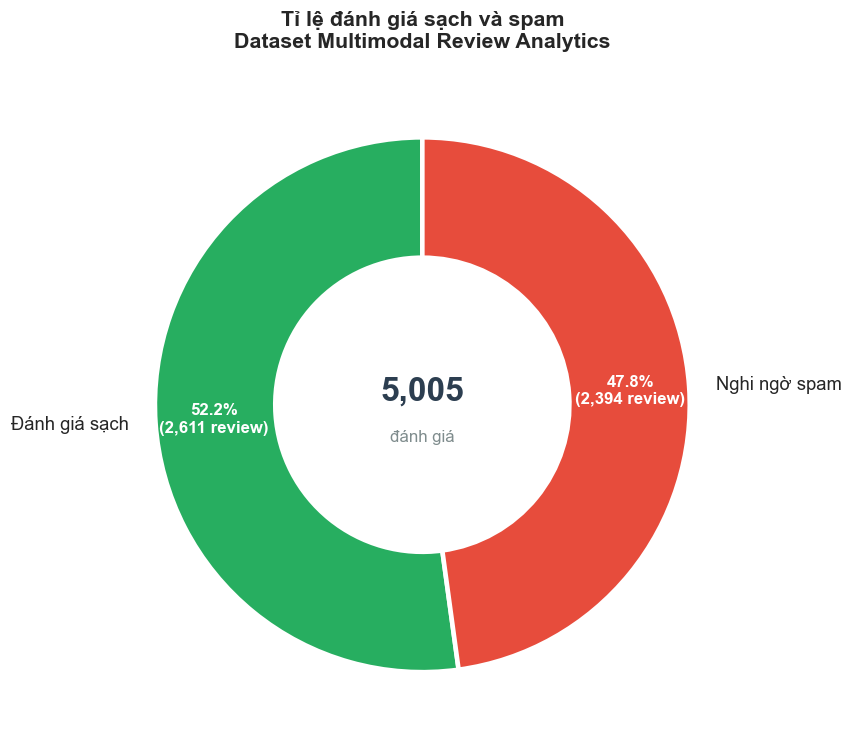

In [58]:
# Vẽ biểu đồ donut tỉ lệ sạch / spam
fig, ax = plt.subplots(figsize=(9, 7))

labels = ["Đánh giá sạch", "Nghi ngờ spam"]
values = [stats["clean_count"], stats["spam_count"]]
colors = [COLOR_CLEAN, COLOR_SPAM]

wedges, texts, autotexts = ax.pie(
    values, labels=labels, colors=colors,
    autopct=lambda p: f"{p:.1f}%\n({int(round(p/100.*sum(values))):,} review)",
    startangle=90,
    textprops={"fontsize": 12},
    wedgeprops={"edgecolor": "white", "linewidth": 3, "width": 0.45},
    pctdistance=0.78,
)
for t in autotexts:
    t.set_fontweight("bold")
    t.set_color("white")
    t.set_fontsize(11)

# Thêm chữ ở giữa donut cho đẹp
ax.text(0, 0.05, f"{stats['total_reviews']:,}",
        ha="center", va="center", fontsize=22, fontweight="bold", color="#2c3e50")
ax.text(0, -0.12, "đánh giá", ha="center", va="center", fontsize=11, color="#7f8c8d")

ax.set_title(f"Tỉ lệ đánh giá sạch và spam\nDataset Multimodal Review Analytics",
             fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

### 5.2. Chi tiết các loại spam phát hiện được

Một đánh giá có thể bị bắt bởi nhiều luật cùng lúc. Bảng và biểu đồ dưới đây cho thấy mỗi luật phát hiện được bao nhiêu trường hợp.

In [59]:
# Lấy thông tin chi tiết theo từng loại luật
breakdown = stats["breakdown"]
df_breakdown = pd.DataFrame([
    {"Loại luật": k, "Số lượng": v["count"], "Tỉ lệ (%)": v["pct"]}
    for k, v in breakdown.items()
]).sort_values("Số lượng", ascending=False).reset_index(drop=True)

display(df_breakdown.style.bar(
    subset=["Số lượng"], color=COLOR_SPAM, vmin=0
).background_gradient(subset=["Tỉ lệ (%)"], cmap="Reds", vmin=0))

,Loại luật,Số lượng,Tỉ lệ (%)
0,Trùng lặp (seeding),1485,29.670000
1,5 sao kèm text rác,703,14.050000
2,Quá ngắn (<3 từ),673,13.450000
3,Mẫu generic / template,322,6.430000
4,Mâu thuẫn rating - nội dung,117,2.340000
5,Spam bàn phím,99,1.980000
6,Bình luận nhận xu,46,0.920000
7,Mã giảm giá rác,11,0.220000
8,Chỉ số và dấu câu,9,0.180000
9,Chỉ toàn emoji,9,0.180000


#### Biểu đồ: Số lượng đánh giá bị bắt theo từng luật

Biểu đồ thanh ngang cho phép đọc tên luật dễ hơn (so với cột dọc) và sắp xếp theo thứ tự giảm dần để thấy ngay luật nào hoạt động mạnh nhất.

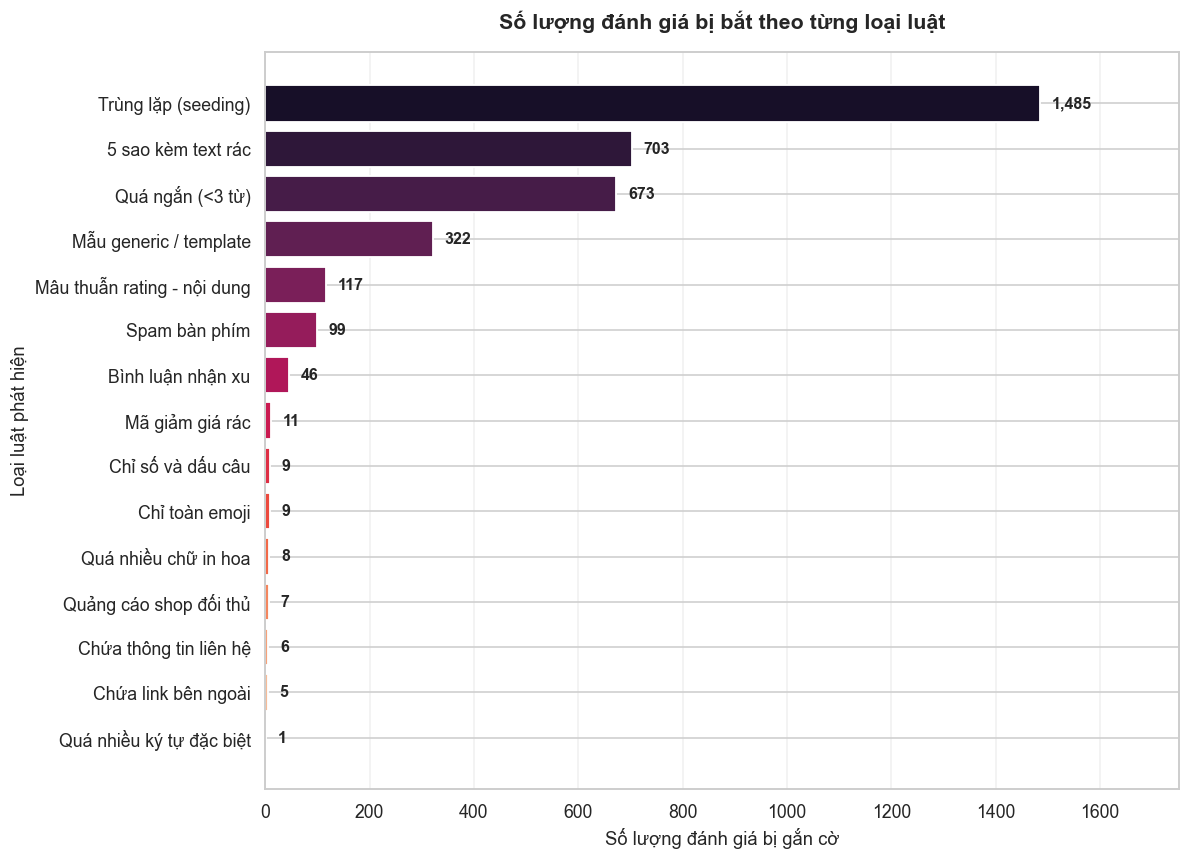

In [60]:
# Vẽ biểu đồ thanh ngang cho dễ đọc tên loại spam
fig, ax = plt.subplots(figsize=(11, 8))

data_plot = df_breakdown[df_breakdown["Số lượng"] > 0].sort_values("Số lượng", ascending=True)
n_bars = len(data_plot)
palette = sns.color_palette("rocket_r", n_colors=n_bars)

bars = ax.barh(data_plot["Loại luật"], data_plot["Số lượng"],
               color=palette, edgecolor="white", linewidth=1.2)

max_val = data_plot["Số lượng"].max()
for bar, count in zip(bars, data_plot["Số lượng"]):
    ax.text(bar.get_width() + max_val * 0.015,
            bar.get_y() + bar.get_height() / 2,
            f"{count:,}",
            va="center", fontsize=10.5, fontweight="bold")

ax.set_xlabel("Số lượng đánh giá bị gắn cờ", fontsize=12)
ax.set_ylabel("Loại luật phát hiện", fontsize=12)
ax.set_title("Số lượng đánh giá bị bắt theo từng loại luật",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlim(0, max_val * 1.18)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### 5.3. Phân bố rating của đánh giá spam và sạch

Câu hỏi: liệu spam có tập trung ở rating cao không? Lý thuyết là seeding thường để 5 sao để đẩy điểm sản phẩm lên, còn review thật phân bố đều hơn.

In [61]:
# Tính phân bố rating cho hai nhóm sạch và spam
rating_dist = (
    df_flagged.groupby(["rating", "is_spam"])
    .size()
    .unstack(fill_value=0)
)
rating_dist.columns = ["Sạch" if c == 0 else "Spam" for c in rating_dist.columns]

# Tính thêm tỉ lệ spam trong mỗi rating
rating_dist["Tổng"] = rating_dist.sum(axis=1)
rating_dist["Tỉ lệ spam (%)"] = (
    rating_dist["Spam"] / rating_dist["Tổng"] * 100
).round(2)
display(rating_dist.style.bar(
    subset=["Tỉ lệ spam (%)"], color=COLOR_SPAM, vmin=0, vmax=100
))

,Sạch,Spam,Tổng,Tỉ lệ spam (%)
rating,,,,
1,64,3,67,4.480000
2,24,4,28,14.290000
3,45,3,48,6.250000
4,105,69,174,39.660000
5,2373,2315,4688,49.380000


#### Biểu đồ: So sánh phân bố rating giữa hai nhóm

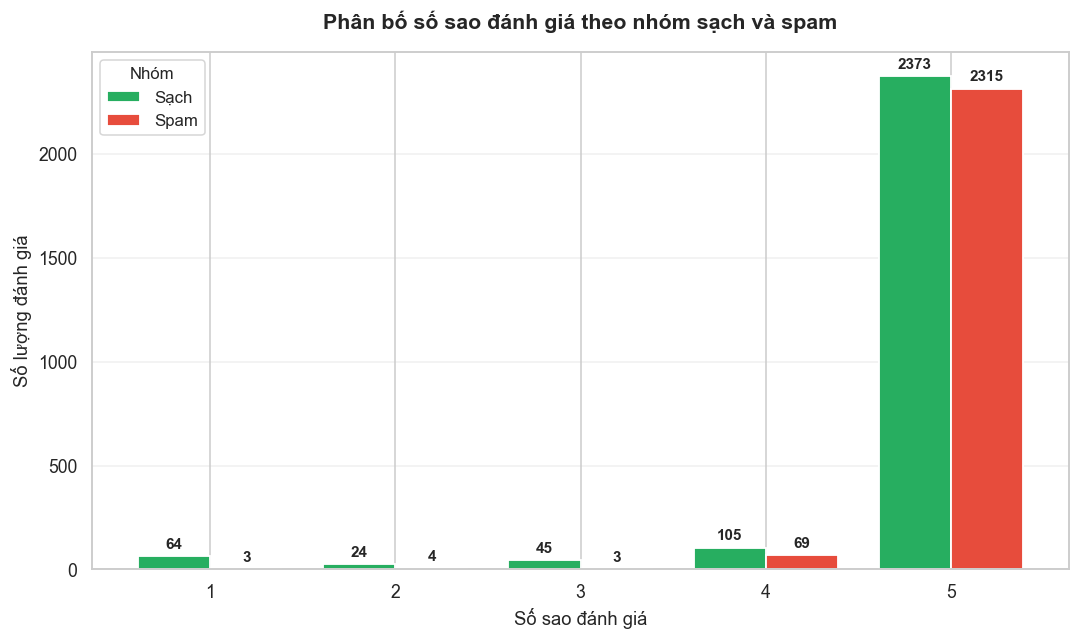

In [62]:
# Biểu đồ cột nhóm so sánh số lượng theo từng mức rating
fig, ax = plt.subplots(figsize=(10, 6))

rating_plot = rating_dist[["Sạch", "Spam"]]
rating_plot.plot(
    kind="bar", ax=ax,
    color=[COLOR_CLEAN, COLOR_SPAM],
    edgecolor="white", linewidth=1.2, width=0.78,
)

for container in ax.containers:
    ax.bar_label(container, fontsize=10, padding=3, fmt="%d", fontweight="bold")

ax.set_xlabel("Số sao đánh giá", fontsize=12)
ax.set_ylabel("Số lượng đánh giá", fontsize=12)
ax.set_title("Phân bố số sao đánh giá theo nhóm sạch và spam",
             fontsize=14, fontweight="bold", pad=15)
ax.legend(title="Nhóm", title_fontsize=11, fontsize=11, loc="upper left")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

#### Biểu đồ: Tỉ lệ spam theo từng mức rating

Biểu đồ này cho thấy rõ hơn rằng tỉ lệ spam thay đổi như thế nào khi rating tăng / giảm.

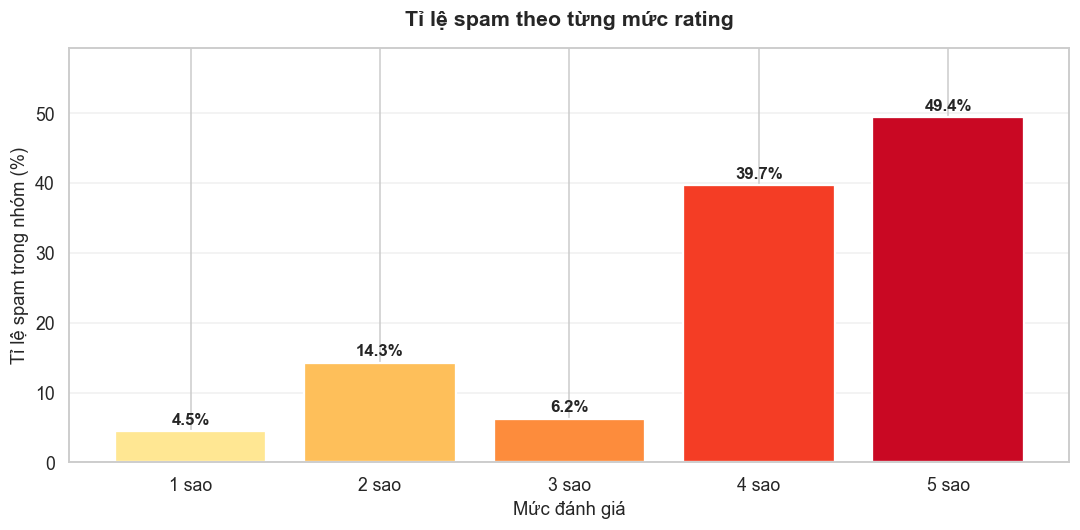

In [63]:
# Vẽ biểu đồ thanh ngang cho tỉ lệ spam ở từng mức rating
fig, ax = plt.subplots(figsize=(10, 5))

rating_data = rating_dist.reset_index()
palette_rating = sns.color_palette("YlOrRd", n_colors=len(rating_data))

bars = ax.bar(
    rating_data["rating"].astype(str) + " sao",
    rating_data["Tỉ lệ spam (%)"],
    color=palette_rating, edgecolor="white", linewidth=1.5,
)
for bar, val in zip(bars, rating_data["Tỉ lệ spam (%)"]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1,
            f"{val:.1f}%",
            ha="center", fontsize=11, fontweight="bold")

ax.set_xlabel("Mức đánh giá", fontsize=12)
ax.set_ylabel("Tỉ lệ spam trong nhóm (%)", fontsize=12)
ax.set_title("Tỉ lệ spam theo từng mức rating",
             fontsize=14, fontweight="bold", pad=15)
ax.set_ylim(0, max(rating_data["Tỉ lệ spam (%)"].max() * 1.2, 10))
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### 5.4. Phân tích độ dài văn bản theo nhóm

#### Tại sao quan tâm độ dài?

Trực giác cho thấy đánh giá quá ngắn dễ là spam (kiểu "ok", "tốt") còn đánh giá dài thường có giá trị thông tin hơn. Phần này kiểm chứng giả thuyết đó bằng cả thống kê mô tả và **kiểm định Mann-Whitney U** (theo gợi ý của đề bài) để xác định liệu hai phân phối độ dài có khác biệt đáng kể về mặt thống kê không.

Mann-Whitney U là kiểm định phi tham số (không cần giả định phân phối chuẩn) so sánh trung vị của hai mẫu độc lập, rất phù hợp với dữ liệu độ dài văn bản vốn lệch phải mạnh.

In [64]:
# Thống kê mô tả độ dài cho hai nhóm
# Lưu ý: dataframe df_flagged có attrs chứa bảng cờ chi tiết (do module spam_filter
# đính kèm), khi groupby().describe() pandas sẽ lỗi "truth value of a DataFrame is
# ambiguous". Vì .copy() vẫn kế thừa attrs nên ta tạo dataframe mới hoàn toàn từ dict
# để cắt đứt mọi attrs.
df_tmp = pd.DataFrame({
    "is_spam": df_flagged["is_spam"].values,
    "word_count": df_flagged["word_count"].values,
    "char_count": df_flagged["char_count"].values,
})

# Tự tính các thống kê mô tả thay vì dùng describe() để chắc chắn không gặp lỗi
def compute_desc(group):
    return pd.Series({
        "count": len(group),
        "mean": group.mean(),
        "std": group.std(),
        "min": group.min(),
        "25%": group.quantile(0.25),
        "50% (median)": group.median(),
        "75%": group.quantile(0.75),
        "max": group.max(),
    })

desc_word = df_tmp.groupby("is_spam")["word_count"].apply(compute_desc).unstack().round(2)
desc_char = df_tmp.groupby("is_spam")["char_count"].apply(compute_desc).unstack().round(2)

# Đổi index sang nhãn dễ đọc
desc_word.index = ["Sạch", "Spam"]
desc_char.index = ["Sạch", "Spam"]

print("Thống kê mô tả số TỪ theo nhóm:")
display(desc_word)

print()
print("Thống kê mô tả số KÝ TỰ theo nhóm:")
display(desc_char)

Thống kê mô tả số TỪ theo nhóm:


,count,mean,std,min,25%,50% (median),75%,max
Sạch,2611.0,20.86,14.70,3.0,11.0,19.0,27.0,174.0
Spam,2394.0,19.04,19.28,0.0,2.0,18.0,27.0,292.0



Thống kê mô tả số KÝ TỰ theo nhóm:


,count,mean,std,min,25%,50% (median),75%,max
Sạch,2611.0,94.73,67.51,7.0,50.0,84.0,122.0,763.0
Spam,2394.0,88.43,88.16,1.0,9.0,86.0,127.0,1315.0


In [65]:
# Kiểm định Mann-Whitney U cho số từ
clean_words = df_flagged[df_flagged["is_spam"] == 0]["word_count"]
spam_words = df_flagged[df_flagged["is_spam"] == 1]["word_count"]

u_stat, p_value = scipy_stats.mannwhitneyu(
    clean_words, spam_words, alternative="two-sided"
)

print("Kết quả kiểm định Mann-Whitney U trên số từ:")
print(f"  U-statistic   : {u_stat:,.0f}")
print(f"  p-value       : {p_value:.6e}")
print(f"  Trung vị sạch : {clean_words.median():.0f} từ")
print(f"  Trung vị spam : {spam_words.median():.0f} từ")
print()
if p_value < 0.001:
    print("  Kết luận: Hai nhóm có độ dài KHÁC BIỆT RẤT RÕ RỆT về mặt thống kê (p < 0.001).")
elif p_value < 0.05:
    print("  Kết luận: Hai nhóm có độ dài khác biệt có ý nghĩa thống kê (p < 0.05).")
else:
    print("  Kết luận: Không đủ bằng chứng để kết luận hai nhóm khác biệt về độ dài.")

Kết quả kiểm định Mann-Whitney U trên số từ:
  U-statistic   : 3,536,265
  p-value       : 8.181629e-16
  Trung vị sạch : 19 từ
  Trung vị spam : 18 từ

  Kết luận: Hai nhóm có độ dài KHÁC BIỆT RẤT RÕ RỆT về mặt thống kê (p < 0.001).


#### Biểu đồ: Phân bố độ dài văn bản theo nhóm

Dùng box plot kết hợp violin plot để vừa thấy được trung vị, tứ phân vị, vừa thấy được mật độ phân bố.

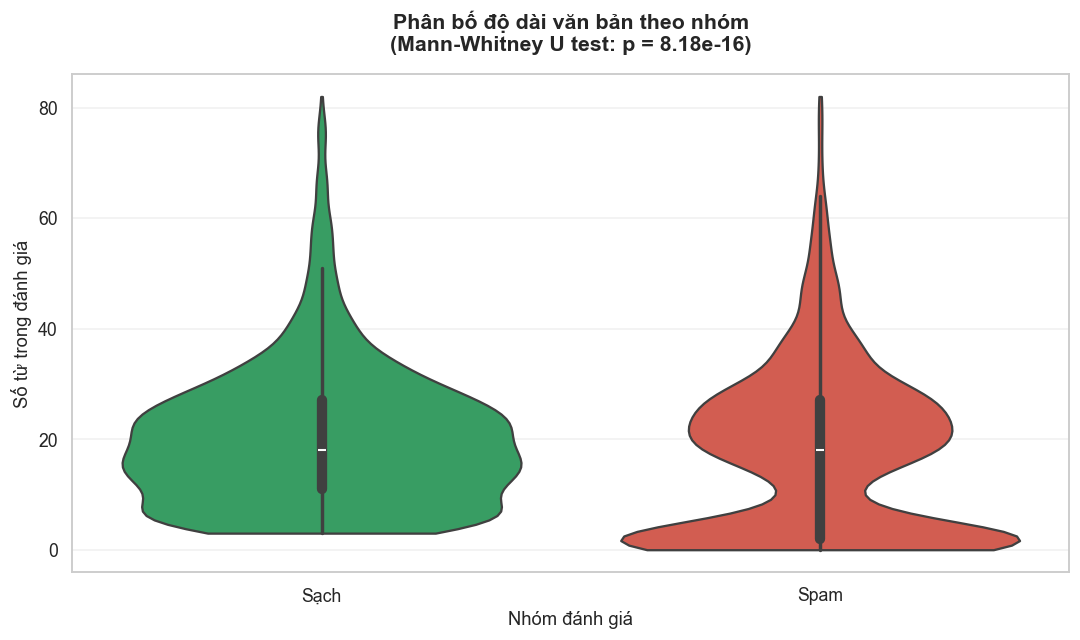

In [66]:
# Lọc các giá trị quá lớn (top 1%) để biểu đồ dễ nhìn
upper_limit = df_flagged["word_count"].quantile(0.99)
df_plot = df_flagged[df_flagged["word_count"] <= upper_limit].copy()
df_plot["Nhóm"] = df_plot["is_spam"].map({0: "Sạch", 1: "Spam"})

fig, ax = plt.subplots(figsize=(10, 6))

sns.violinplot(
    data=df_plot, x="Nhóm", y="word_count", ax=ax,
    palette=[COLOR_CLEAN, COLOR_SPAM],
    inner="box", linewidth=1.5, cut=0,
)

ax.set_xlabel("Nhóm đánh giá", fontsize=12)
ax.set_ylabel("Số từ trong đánh giá", fontsize=12)
ax.set_title(f"Phân bố độ dài văn bản theo nhóm\n"
             f"(Mann-Whitney U test: p = {p_value:.2e})",
             fontsize=14, fontweight="bold", pad=15)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### 5.5. Tỉ lệ spam theo dải độ dài văn bản

Câu hỏi cụ thể hơn: review càng ngắn thì tỉ lệ spam càng cao đúng không? Cắt độ dài thành nhiều dải để xem xu hướng.

In [67]:
# Cắt số từ thành các dải logical
bins = [0, 3, 7, 15, 30, 60, 100, 100000]
bin_labels = ["1-3", "4-7", "8-15", "16-30", "31-60", "61-100", ">100"]

df_flagged["length_bin"] = pd.cut(
    df_flagged["word_count"], bins=bins, labels=bin_labels, right=True
)

length_table = (
    df_flagged.groupby("length_bin", observed=True)
    .agg(total=("is_spam", "size"), spam_count=("is_spam", "sum"))
)
length_table["spam_pct"] = (
    length_table["spam_count"] / length_table["total"] * 100
).round(2)
length_table.columns = ["Tổng review", "Số spam", "Tỉ lệ spam (%)"]
display(length_table.style.bar(
    subset=["Tỉ lệ spam (%)"], color=COLOR_SPAM, vmin=0, vmax=100
))

,Tổng review,Số spam,Tỉ lệ spam (%)
length_bin,,,
1-3,837,758,90.560000
4-7,443,98,22.120000
8-15,759,141,18.580000
16-30,2086,967,46.360000
31-60,760,363,47.760000
61-100,90,45,50.000000
>100,24,16,66.670000


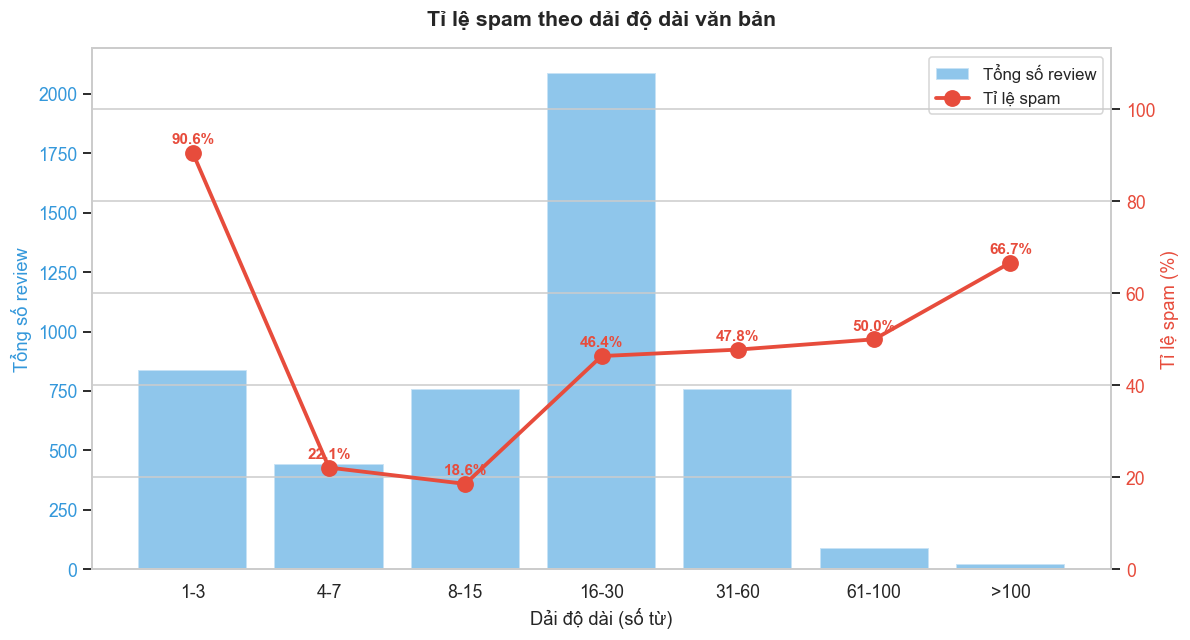

In [68]:
# Vẽ biểu đồ kết hợp: cột thể hiện số lượng + đường line tỉ lệ spam
fig, ax1 = plt.subplots(figsize=(11, 6))

x_pos = np.arange(len(length_table))
ax1.bar(x_pos, length_table["Tổng review"],
        color=COLOR_NEUTRAL, alpha=0.55, edgecolor="white", linewidth=1.2,
        label="Tổng số review")
ax1.set_xlabel("Dải độ dài (số từ)", fontsize=12)
ax1.set_ylabel("Tổng số review", fontsize=12, color=COLOR_NEUTRAL)
ax1.tick_params(axis="y", labelcolor=COLOR_NEUTRAL)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(length_table.index)

# Trục y bên phải cho tỉ lệ spam
ax2 = ax1.twinx()
ax2.plot(x_pos, length_table["Tỉ lệ spam (%)"],
         color=COLOR_SPAM, marker="o", markersize=10, linewidth=2.5,
         label="Tỉ lệ spam")
for i, val in enumerate(length_table["Tỉ lệ spam (%)"]):
    ax2.text(i, val + 2, f"{val:.1f}%", ha="center",
             fontsize=10, fontweight="bold", color=COLOR_SPAM)
ax2.set_ylabel("Tỉ lệ spam (%)", fontsize=12, color=COLOR_SPAM)
ax2.tick_params(axis="y", labelcolor=COLOR_SPAM)
ax2.set_ylim(0, max(length_table["Tỉ lệ spam (%)"].max() * 1.25, 10))

plt.title("Tỉ lệ spam theo dải độ dài văn bản",
          fontsize=14, fontweight="bold", pad=15)

# Gộp legend của hai trục
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=11)
ax1.grid(False)
plt.tight_layout()
plt.show()

### 5.6. Top từ vựng và Word Cloud theo nhóm

Theo gợi ý của đề bài, ta vẽ word cloud và bảng top-50 từ phổ biến nhất cho từng lớp. Việc này giúp hiểu được spam và review thật khác nhau ở mặt từ vựng như thế nào.

In [69]:
# Hàm tách từ và đếm tần suất
import re as _re

def tokenize_simple(text):
    """Tách từ đơn giản: lowercase, bỏ ký tự đặc biệt, split theo khoảng trắng."""
    text = remove_emojis(normalize_text(text))
    text = _re.sub(r"[^\w\s]", " ", text, flags=_re.UNICODE)
    return [w for w in text.split() if len(w) >= 2]

# Đếm tần suất từ cho mỗi nhóm
print("Đang đếm tần suất từ trong nhóm sạch và nhóm spam...")
clean_tokens = []
for t in df_flagged[df_flagged["is_spam"] == 0]["text"]:
    clean_tokens.extend(tokenize_simple(t))
spam_tokens = []
for t in df_flagged[df_flagged["is_spam"] == 1]["text"]:
    spam_tokens.extend(tokenize_simple(t))

clean_freq = Counter(clean_tokens)
spam_freq = Counter(spam_tokens)

print(f"Số token trong nhóm sạch: {len(clean_tokens):,}")
print(f"Số token trong nhóm spam: {len(spam_tokens):,}")

Đang đếm tần suất từ trong nhóm sạch và nhóm spam...
Số token trong nhóm sạch: 53,420
Số token trong nhóm spam: 45,320


#### Bảng top-20 từ phổ biến nhất trong nhóm sạch và nhóm spam

In [70]:
# Tạo bảng top 20 cho mỗi nhóm để so sánh
top_n = 20
top_clean = pd.DataFrame(clean_freq.most_common(top_n),
                         columns=["Từ (sạch)", "Tần suất (sạch)"])
top_spam = pd.DataFrame(spam_freq.most_common(top_n),
                        columns=["Từ (spam)", "Tần suất (spam)"])
top_combined = pd.concat([top_clean, top_spam], axis=1)
display(top_combined)

,Từ (sạch),Tần suất (sạch),Từ (spam),Tần suất (spam)
0,hàng,1098,cho,1276
1,cho,865,và,928
2,giao,799,tăng,789
3,và,786,để,727
4,nhanh,662,phát,648
5,chất,648,triển,647
6,lượng,639,lượng,630
7,rất,567,thức,575
8,mua,540,công,574
9,gói,506,tốt,561


#### Word Cloud cho nhóm sạch

Chưa cài thư viện wordcloud. Chạy: pip install wordcloud


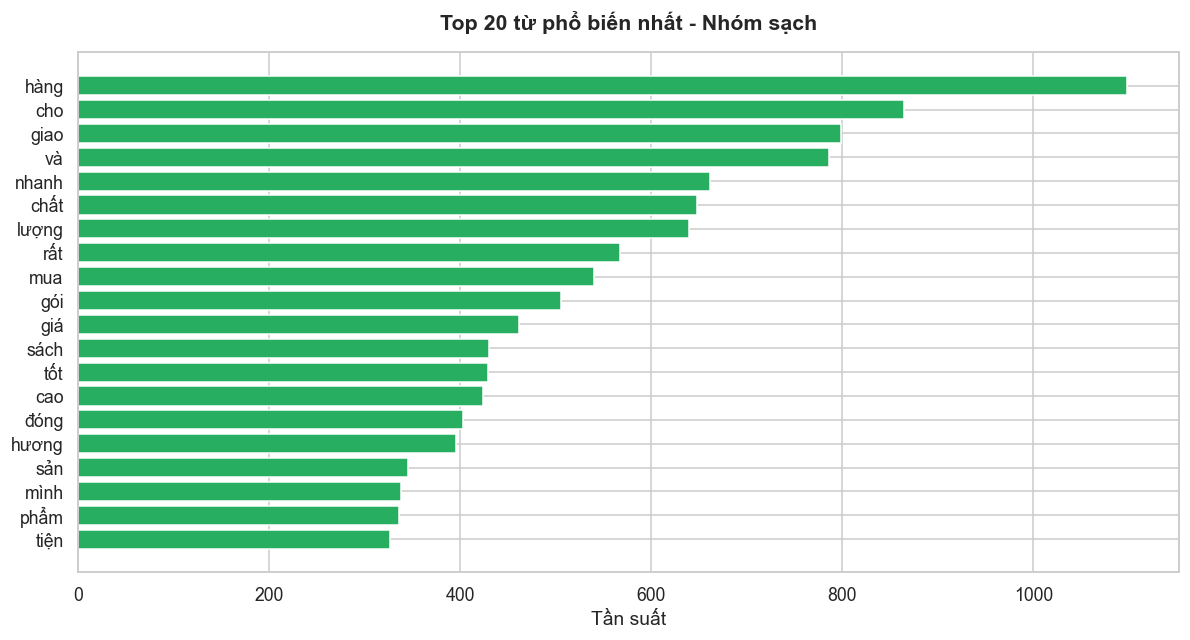

In [71]:
# Vẽ word cloud cho nhóm sạch
try:
    from wordcloud import WordCloud
    
    wc_clean = WordCloud(
        width=900, height=500,
        background_color="white",
        colormap="Greens",
        max_words=100,
        relative_scaling=0.5,
        prefer_horizontal=0.9,
    ).generate_from_frequencies(clean_freq)

    fig, ax = plt.subplots(figsize=(11, 6))
    ax.imshow(wc_clean, interpolation="bilinear")
    ax.axis("off")
    ax.set_title("Word Cloud - Nhóm đánh giá SẠCH",
                 fontsize=14, fontweight="bold", pad=15, color=COLOR_CLEAN)
    plt.tight_layout()
    plt.show()
except ImportError:
    print("Chưa cài thư viện wordcloud. Chạy: pip install wordcloud")
    # Fallback: vẽ biểu đồ cột top 20 thay thế
    fig, ax = plt.subplots(figsize=(11, 6))
    top20_clean = clean_freq.most_common(20)
    words, freqs = zip(*top20_clean)
    ax.barh(words[::-1], freqs[::-1], color=COLOR_CLEAN, edgecolor="white")
    ax.set_title("Top 20 từ phổ biến nhất - Nhóm sạch",
                 fontsize=14, fontweight="bold", pad=15)
    ax.set_xlabel("Tần suất")
    plt.tight_layout()
    plt.show()

#### Word Cloud cho nhóm spam

Chưa cài thư viện wordcloud. Chạy: pip install wordcloud


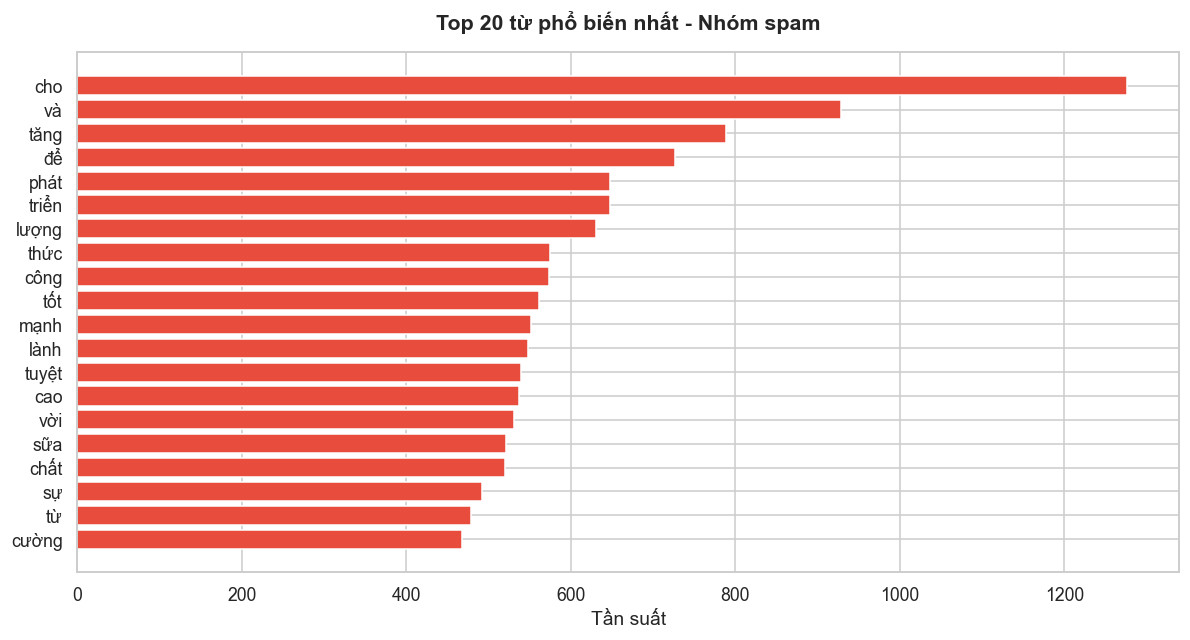

In [72]:
# Vẽ word cloud cho nhóm spam
try:
    from wordcloud import WordCloud
    
    wc_spam = WordCloud(
        width=900, height=500,
        background_color="white",
        colormap="Reds",
        max_words=100,
        relative_scaling=0.5,
        prefer_horizontal=0.9,
    ).generate_from_frequencies(spam_freq)

    fig, ax = plt.subplots(figsize=(11, 6))
    ax.imshow(wc_spam, interpolation="bilinear")
    ax.axis("off")
    ax.set_title("Word Cloud - Nhóm đánh giá SPAM",
                 fontsize=14, fontweight="bold", pad=15, color=COLOR_SPAM)
    plt.tight_layout()
    plt.show()
except ImportError:
    print("Chưa cài thư viện wordcloud. Chạy: pip install wordcloud")
    # Fallback
    fig, ax = plt.subplots(figsize=(11, 6))
    top20_spam = spam_freq.most_common(20)
    words, freqs = zip(*top20_spam)
    ax.barh(words[::-1], freqs[::-1], color=COLOR_SPAM, edgecolor="white")
    ax.set_title("Top 20 từ phổ biến nhất - Nhóm spam",
                 fontsize=14, fontweight="bold", pad=15)
    ax.set_xlabel("Tần suất")
    plt.tight_layout()
    plt.show()

### 5.7. Type-Token Ratio (TTR) đánh giá độ phong phú từ vựng

Type-Token Ratio = số từ duy nhất / tổng số từ. Theo gợi ý của đề bài, đây là chỉ số đo độ phong phú từ vựng:

- **TTR cao** (gần 1.0): mỗi từ chỉ xuất hiện một lần → văn bản đa dạng từ vựng.
- **TTR thấp** (gần 0): nhiều từ bị lặp → văn bản nghèo nàn, có thể là spam.

Giả thuyết: nhóm spam có TTR thấp hơn nhóm sạch.

In [73]:
# So sánh TTR giữa hai nhóm
# Tạo dataframe mới từ dict để cắt đứt attrs kế thừa
df_tmp_ttr = pd.DataFrame({
    "is_spam": df_flagged["is_spam"].values,
    "ttr": df_flagged["ttr"].values,
})

ttr_stats = df_tmp_ttr.groupby("is_spam")["ttr"].apply(compute_desc).unstack().round(3)
ttr_stats.index = ["Sạch", "Spam"]
display(ttr_stats)

,count,mean,std,min,25%,50% (median),75%,max
Sạch,2611.0,0.940,0.095,0.056,0.909,0.969,1.0,1.0
Spam,2394.0,0.927,0.143,0.000,0.917,1.000,1.0,1.0


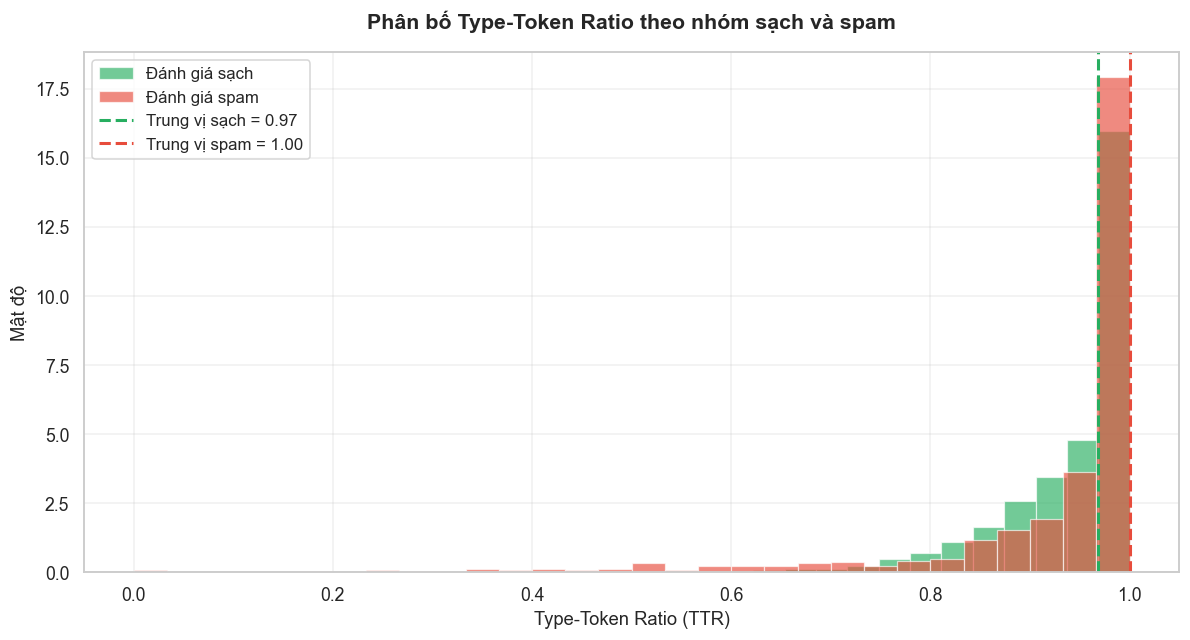

In [74]:
# Vẽ histogram TTR cho hai nhóm
fig, ax = plt.subplots(figsize=(11, 6))

ax.hist(df_flagged[df_flagged["is_spam"] == 0]["ttr"],
        bins=30, alpha=0.65, color=COLOR_CLEAN,
        label="Đánh giá sạch", edgecolor="white", linewidth=0.8, density=True)
ax.hist(df_flagged[df_flagged["is_spam"] == 1]["ttr"],
        bins=30, alpha=0.65, color=COLOR_SPAM,
        label="Đánh giá spam", edgecolor="white", linewidth=0.8, density=True)

# Thêm đường trung vị của mỗi nhóm
median_clean = df_flagged[df_flagged["is_spam"] == 0]["ttr"].median()
median_spam = df_flagged[df_flagged["is_spam"] == 1]["ttr"].median()
ax.axvline(median_clean, color=COLOR_CLEAN, linestyle="--", linewidth=2,
           label=f"Trung vị sạch = {median_clean:.2f}")
ax.axvline(median_spam, color=COLOR_SPAM, linestyle="--", linewidth=2,
           label=f"Trung vị spam = {median_spam:.2f}")

ax.set_xlabel("Type-Token Ratio (TTR)", fontsize=12)
ax.set_ylabel("Mật độ", fontsize=12)
ax.set_title("Phân bố Type-Token Ratio theo nhóm sạch và spam",
             fontsize=14, fontweight="bold", pad=15)
ax.legend(fontsize=11, loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 5.8. Phân phối Zipf của tần suất từ

Định luật Zipf nói rằng tần suất của từ thứ k phổ biến nhất tỉ lệ nghịch với k. Trên đồ thị log-log, mối quan hệ này gần như là một đường thẳng đi xuống.

#### Tại sao quan tâm Zipf cho spam?

Văn bản tự nhiên của con người tuân theo định luật Zipf khá tốt. Nếu phân bố tần suất từ trong dữ liệu lệch khỏi Zipf đáng kể, đó là dấu hiệu của văn bản nhân tạo (sinh bởi máy hoặc copy-paste). Phần này so sánh phân phối Zipf của nhóm sạch và nhóm spam.

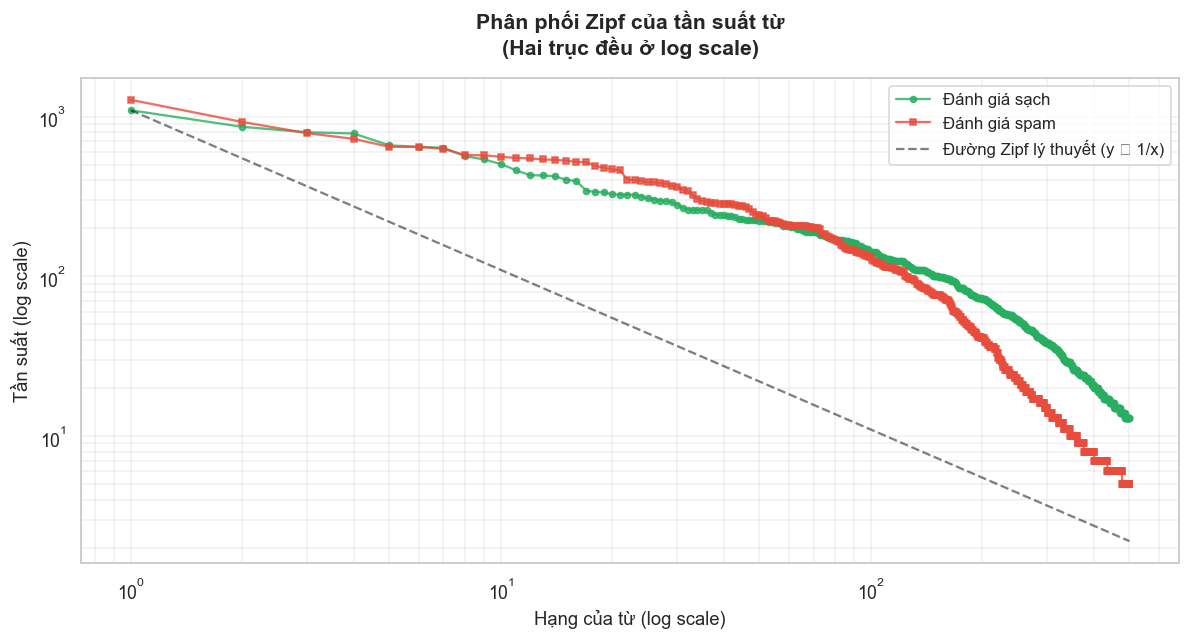

In [75]:
# Tính rank và frequency cho cả hai nhóm
def get_zipf_data(freq_counter, top_k=500):
    """Trả về (ranks, frequencies) sắp xếp theo thứ tự giảm dần."""
    sorted_freq = sorted(freq_counter.values(), reverse=True)[:top_k]
    ranks = np.arange(1, len(sorted_freq) + 1)
    return ranks, np.array(sorted_freq)

ranks_clean, freqs_clean = get_zipf_data(clean_freq, top_k=500)
ranks_spam, freqs_spam = get_zipf_data(spam_freq, top_k=500)

# Vẽ trên đồ thị log-log
fig, ax = plt.subplots(figsize=(11, 6))

ax.loglog(ranks_clean, freqs_clean, marker="o", markersize=4,
          linewidth=1.5, color=COLOR_CLEAN, alpha=0.8,
          label="Đánh giá sạch")
ax.loglog(ranks_spam, freqs_spam, marker="s", markersize=4,
          linewidth=1.5, color=COLOR_SPAM, alpha=0.8,
          label="Đánh giá spam")

# Vẽ đường lý thuyết Zipf y = c/x để so sánh
if len(freqs_clean) > 0:
    c = freqs_clean[0]
    ax.loglog(ranks_clean, c / ranks_clean, "k--", alpha=0.5, linewidth=1.5,
              label="Đường Zipf lý thuyết (y ∝ 1/x)")

ax.set_xlabel("Hạng của từ (log scale)", fontsize=12)
ax.set_ylabel("Tần suất (log scale)", fontsize=12)
ax.set_title("Phân phối Zipf của tần suất từ\n(Hai trục đều ở log scale)",
             fontsize=14, fontweight="bold", pad=15)
ax.legend(fontsize=11)
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

### 5.9. Vector hóa TF-IDF và t-SNE 2D

Theo gợi ý của đề bài, ta vector hóa văn bản bằng TF-IDF rồi giảm chiều xuống 2D bằng t-SNE để trực quan hóa khả năng tách biệt giữa hai lớp. Sau đó tính **silhouette score** để định lượng độ tách biệt.

#### Tại sao là TF-IDF + t-SNE?

- **TF-IDF** biến mỗi văn bản thành một vector trong không gian từ vựng cao chiều.
- **t-SNE** chiếu vector đó xuống 2D sao cho các điểm gần nhau trong không gian gốc vẫn gần nhau trong 2D.
- Nếu spam và sạch tách biệt tốt trong không gian TF-IDF, ta sẽ thấy hai cụm rõ ràng trên biểu đồ t-SNE.

In [76]:
# Vector hóa TF-IDF với unigram + bigram
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

# Lấy mẫu để tăng tốc nếu data quá lớn (t-SNE chậm với > 5000 mẫu)
sample_size = min(3000, len(df_flagged))
df_sample = df_flagged.sample(n=sample_size, random_state=42).reset_index(drop=True)

print(f"Đang vector hóa TF-IDF cho {len(df_sample):,} mẫu...")
vectorizer = TfidfVectorizer(
    max_features=2000, ngram_range=(1, 2), min_df=2, max_df=0.95
)
tfidf_matrix = vectorizer.fit_transform(df_sample["text_clean"].fillna(""))
print(f"Số chiều TF-IDF: {tfidf_matrix.shape[1]:,}")
print(f"Độ thưa (sparsity): {1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1]):.4f}")

Đang vector hóa TF-IDF cho 3,000 mẫu...
Số chiều TF-IDF: 2,000
Độ thưa (sparsity): 0.9858


In [78]:
# Chạy t-SNE giảm chiều xuống 2D
print("Đang chạy t-SNE để giảm chiều xuống 2D (có thể mất 30-60 giây)...")
tsne = TSNE(
    n_components=2, perplexity=30, random_state=42,
    init="random", learning_rate=200, max_iter=1000,
)
tsne_coords = tsne.fit_transform(tfidf_matrix.toarray())
print("Hoàn tất t-SNE")

# Tính silhouette score để định lượng độ tách biệt
labels_sample = df_sample["is_spam"].values
sil_score = silhouette_score(tsne_coords, labels_sample, metric="euclidean")
print(f"Silhouette score trên không gian t-SNE 2D: {sil_score:.4f}")
print()
if sil_score > 0.3:
    print("Hai nhóm tách biệt khá rõ ràng (silhouette > 0.3).")
elif sil_score > 0.1:
    print("Hai nhóm có khả năng tách biệt vừa phải (0.1 < silhouette < 0.3).")
else:
    print("Hai nhóm khá chồng lấp trong không gian TF-IDF (silhouette < 0.1).")

Đang chạy t-SNE để giảm chiều xuống 2D (có thể mất 30-60 giây)...
Hoàn tất t-SNE
Silhouette score trên không gian t-SNE 2D: 0.0208

Hai nhóm khá chồng lấp trong không gian TF-IDF (silhouette < 0.1).


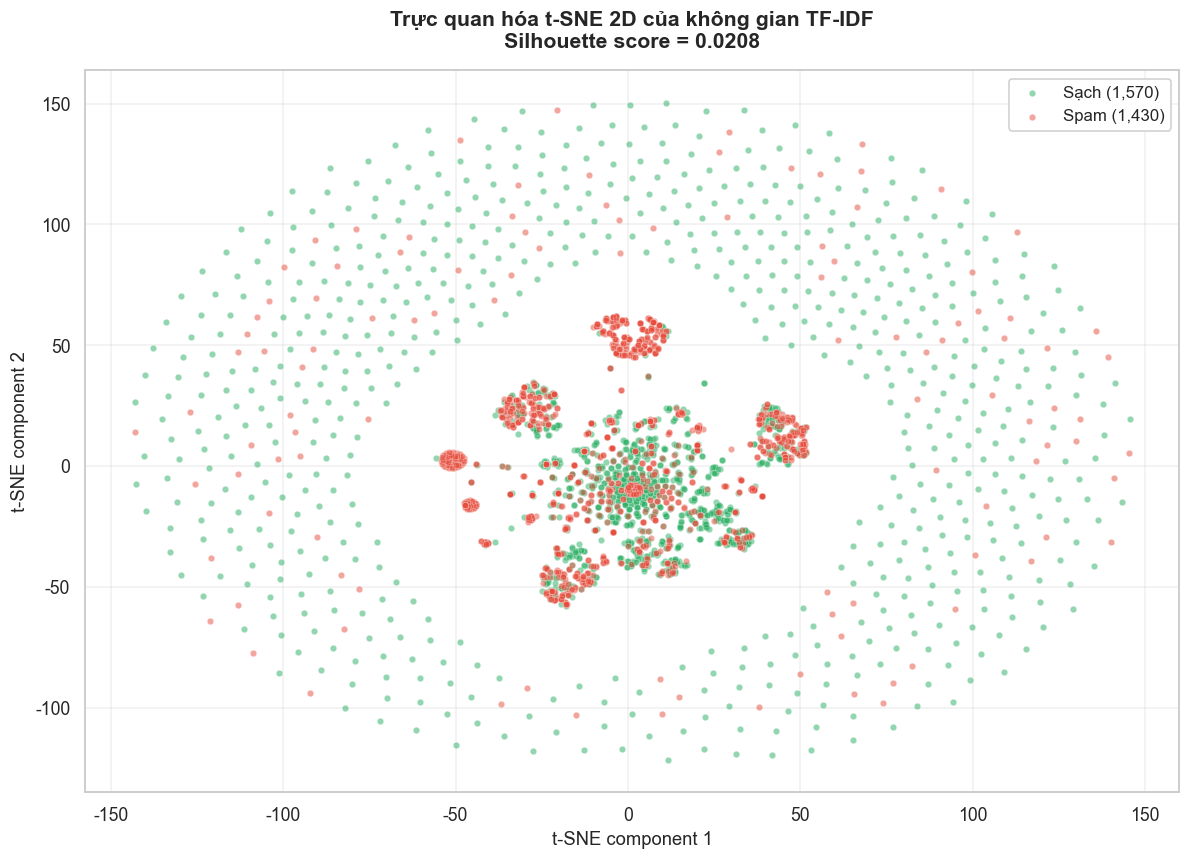

In [79]:
# Vẽ biểu đồ scatter t-SNE 2D, tô màu theo nhãn
fig, ax = plt.subplots(figsize=(11, 8))

mask_clean = labels_sample == 0
mask_spam = labels_sample == 1

ax.scatter(tsne_coords[mask_clean, 0], tsne_coords[mask_clean, 1],
           c=COLOR_CLEAN, alpha=0.5, s=18, edgecolors="white",
           linewidth=0.3, label=f"Sạch ({mask_clean.sum():,})")
ax.scatter(tsne_coords[mask_spam, 0], tsne_coords[mask_spam, 1],
           c=COLOR_SPAM, alpha=0.5, s=18, edgecolors="white",
           linewidth=0.3, label=f"Spam ({mask_spam.sum():,})")

ax.set_xlabel("t-SNE component 1", fontsize=12)
ax.set_ylabel("t-SNE component 2", fontsize=12)
ax.set_title(f"Trực quan hóa t-SNE 2D của không gian TF-IDF\n"
             f"Silhouette score = {sil_score:.4f}",
             fontsize=14, fontweight="bold", pad=15)
ax.legend(fontsize=11, loc="best", framealpha=0.95)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 5.10. Heatmap tương quan giữa các đặc trưng

Phân tích tương quan giữa các đặc trưng để phát hiện multicollinearity (theo yêu cầu của đề bài) và xem đặc trưng nào liên quan mạnh nhất đến nhãn `is_spam`.

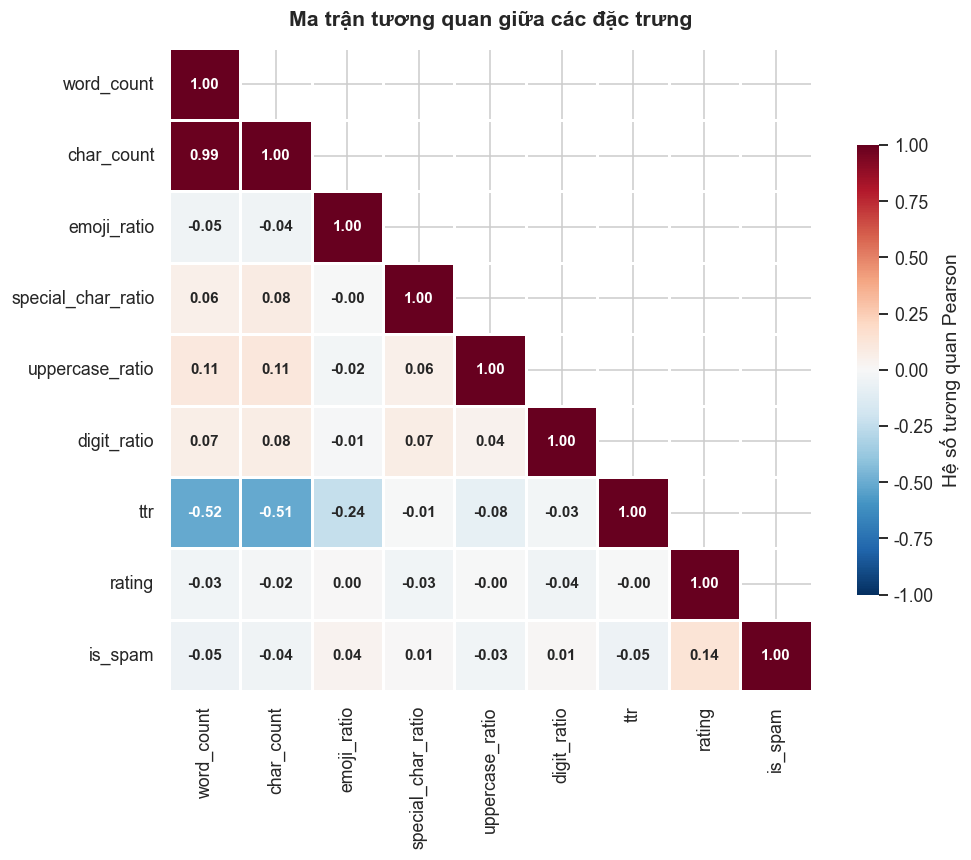

In [80]:
# Tính ma trận tương quan Pearson giữa các đặc trưng
corr_cols = ["word_count", "char_count", "emoji_ratio", "special_char_ratio",
             "uppercase_ratio", "digit_ratio", "ttr", "rating", "is_spam"]
corr_matrix = df_flagged[corr_cols].corr()

# Vẽ heatmap đẹp
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(
    corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
    vmin=-1, vmax=1, square=True, linewidths=0.8, linecolor="white",
    cbar_kws={"shrink": 0.7, "label": "Hệ số tương quan Pearson"},
    annot_kws={"fontsize": 10, "fontweight": "bold"},
    mask=mask, ax=ax,
)
ax.set_title("Ma trận tương quan giữa các đặc trưng",
             fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

### 5.11. Phát hiện ngoại lệ và mẫu điển hình

#### Phát hiện ngoại lệ độ dài bằng phương pháp IQR

Theo gợi ý của đề bài, ta dùng phương pháp Interquartile Range (IQR) để xác định ngoại lệ trong phân bố độ dài văn bản.

In [81]:
# Phát hiện ngoại lệ độ dài bằng IQR
q1 = df_flagged["word_count"].quantile(0.25)
q3 = df_flagged["word_count"].quantile(0.75)
iqr = q3 - q1
upper_outlier = q3 + 1.5 * iqr
lower_outlier = max(0, q1 - 1.5 * iqr)

n_upper = (df_flagged["word_count"] > upper_outlier).sum()
n_lower = (df_flagged["word_count"] < lower_outlier).sum()

print(f"Q1 (25%) : {q1:.0f} từ")
print(f"Q3 (75%) : {q3:.0f} từ")
print(f"IQR      : {iqr:.0f} từ")
print(f"Ngưỡng ngoại lệ trên: {upper_outlier:.0f} từ")
print(f"Ngưỡng ngoại lệ dưới: {lower_outlier:.0f} từ")
print()
print(f"Số ngoại lệ trên (review quá dài): {n_upper:,} ({n_upper/len(df_flagged)*100:.2f}%)")
print(f"Số ngoại lệ dưới (review quá ngắn): {n_lower:,} ({n_lower/len(df_flagged)*100:.2f}%)")

Q1 (25%) : 7 từ
Q3 (75%) : 27 từ
IQR      : 20 từ
Ngưỡng ngoại lệ trên: 57 từ
Ngưỡng ngoại lệ dưới: 0 từ

Số ngoại lệ trên (review quá dài): 137 (2.74%)
Số ngoại lệ dưới (review quá ngắn): 0 (0.00%)


#### Mẫu đánh giá điển hình của nhóm SPAM

Hiển thị một vài mẫu để xác minh trực quan rằng bộ luật hoạt động đúng.

In [82]:
# Lấy ngẫu nhiên một số mẫu spam
df_spam = df_flagged[df_flagged["is_spam"] == 1]
n_show = min(8, len(df_spam))

if n_show > 0:
    samples = df_spam.sample(n=n_show, random_state=42)
    cols_show = ["text", "rating", "word_count"]
    cols_avail = [c for c in cols_show if c in samples.columns]
    samples_display = samples[cols_avail].copy()
    samples_display["text"] = samples_display["text"].astype(str).apply(
        lambda x: x[:120] + ("..." if len(x) > 120 else "")
    )
    display(samples_display.style.set_caption("Mẫu đánh giá bị gắn cờ SPAM").set_table_styles([
        {"selector": "caption", "props": [("color", COLOR_SPAM), ("font-size", "14px"), ("font-weight", "bold")]}
    ]))
else:
    print("Không có mẫu spam nào để hiển thị")

,text,rating,word_count
599,"Hoàn hảo cho một bữa ăn nhẹ nhanh và lành mạnh, Bao bì tiện lợi để mang theo, Tăng cường hệ thống miễn dịch và thúc đẩy ...",5,29
257,"Công thức sữa tốt nhất cho bé của tôi., Công thức bột tiện lợi để chuẩn bị dễ dàng, Rất khuyến khích cho trẻ từ 12-24 th...",5,28
2763,"Giá trị tuyệt vời cho số tiền bỏ ra,",5,9
3908,Giao nhanh,5,2
4250,Ngon,5,1
393,"Rất khuyến khích cho trẻ từ 12-24 tháng tuổi., Giúp hỗ trợ sự phát triển và tăng trưởng tổng thể.,",5,20
4951,Ko,5,1
3203,tốt,5,1


#### Mẫu đánh giá điển hình của nhóm SẠCH

Đối chiếu để thấy sự khác biệt rõ ràng giữa hai nhóm.

In [83]:
# Lấy ngẫu nhiên một số mẫu sạch
df_clean = df_flagged[df_flagged["is_spam"] == 0]
n_show = min(8, len(df_clean))

if n_show > 0:
    samples = df_clean.sample(n=n_show, random_state=42)
    cols_show = ["text", "rating", "word_count"]
    cols_avail = [c for c in cols_show if c in samples.columns]
    samples_display = samples[cols_avail].copy()
    samples_display["text"] = samples_display["text"].astype(str).apply(
        lambda x: x[:120] + ("..." if len(x) > 120 else "")
    )
    display(samples_display.style.set_caption("Mẫu đánh giá nhóm SẠCH").set_table_styles([
        {"selector": "caption", "props": [("color", COLOR_CLEAN), ("font-size", "14px"), ("font-weight", "bold")]}
    ]))
else:
    print("Không có mẫu sạch nào để hiển thị")

,text,rating,word_count
4982,"Mình thấy đẹp nên mua thử. May mà đã xài qua cục sạc của AVA+ rồi, thấy đợt trước mua ok nên mình mới mua ủng hộ thêm mà...",5,65
2111,rất là thơm nha canh khuyến mại mua được giá tốt shop đóng gói cẩn thận và giao hàng cũng nhanh nữa nói chung là hài lòn...,5,29
736,"Tăng cường hệ thống miễn dịch và thúc đẩy tiêu hóa, Giá trị tuyệt vời cho số tiền bỏ ra, Bao bì lạnh đảm bảo độ tươi,",5,27
3533,Đóng gói cẩn thận Giao hàng nhanh Chất lượng sp tốt,5,11
3105,"sản phẩm đúng với hình, thơm, giao hàng nhanh hơn dự kiến.",5,12
3207,"Tôi rất thích sản phẩm này, da tôi bị gàu rất nhiều, sử dụng thấy có giảm.",5,17
3059,"cũng ok lắm sd mấy lần thôi, môi đã cải thiện rõ rệt vs lại tiki giao hàng nhanh lắm",4,20
741,giá hợp lý so với thị trường bên ngoài,5,9


## 6. Lưu kết quả

Sau khi gán cờ và phân tích xong, ta lưu dataframe ra file CSV để các bước tiếp theo của dự án (huấn luyện mô hình ML, dashboard) có thể sử dụng.

### Lưu ý quan trọng về cấu trúc file output

Theo yêu cầu, file CSV xuất ra **chỉ chứa các cột gốc của dữ liệu cộng thêm đúng một cột mới `is_spam`** (giá trị 0 hoặc 1). Các cột phụ tính toán trong notebook (như `word_count`, `text_clean`, `ttr`, `length_bin`) chỉ phục vụ phân tích nội bộ và không được lưu ra file.

In [84]:
# Xác định danh sách cột cần lưu: cột gốc của df_raw cộng thêm is_spam
original_cols = [c for c in df_raw.columns if c in df_flagged.columns]
export_cols = original_cols + ["is_spam"]

df_export = df_flagged[export_cols].copy()

print(f"Các cột sẽ xuất ra file CSV: {list(df_export.columns)}")
print(f"Tổng số dòng: {len(df_export):,}")
print(f"Phân bố cột is_spam:")
print(df_export["is_spam"].value_counts().to_string())

Các cột sẽ xuất ra file CSV: ['text', 'rating', 'date', 'image_urls', 'product_url', 'scraped_at', 'is_spam']
Tổng số dòng: 5,005
Phân bố cột is_spam:
is_spam
0    2611
1    2394


In [85]:
# Tạo thư mục đích nếu chưa có và lưu file
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
df_export.to_csv(OUTPUT_CSV, index=False, encoding="utf-8-sig")

print(f"Đã lưu file kết quả tại: {OUTPUT_CSV}")
print(f"Dung lượng file: {OUTPUT_CSV.stat().st_size / 1024:.1f} KB")

Đã lưu file kết quả tại: D:\ecommerce-review-analytics\data\processed\reviews_flagged.csv
Dung lượng file: 1738.0 KB


## 7. Tổng kết

Tổng hợp các con số chính và insight rút ra được từ pipeline phân tích spam.

In [86]:
# Tổng hợp lại các con số chính
print("=" * 65)
print("  TÓM TẮT KẾT QUẢ PHÂN TÍCH SPAM")
print("=" * 65)
print()
print(f"  Tổng số đánh giá xử lý : {stats['total_reviews']:,}")
print(f"  Đánh giá sạch          : {stats['clean_count']:,} ({stats['clean_pct']}%)")
print(f"  Đánh giá nghi spam     : {stats['spam_count']:,} ({stats['spam_pct']}%)")
print()
print(f"  Top 5 loại spam phổ biến nhất:")
top5 = df_breakdown.head(5)
for _, row in top5.iterrows():
    print(f"    - {row['Loại luật']:<35} {row['Số lượng']:>6,} ({row['Tỉ lệ (%)']:>5.2f}%)")
print()
print(f"  Kiểm định Mann-Whitney U:")
print(f"    - p-value = {p_value:.2e}")
print(f"    - Trung vị độ dài (sạch / spam): {clean_words.median():.0f} / {spam_words.median():.0f} từ")
print()
print(f"  Silhouette score (TF-IDF + t-SNE 2D): {sil_score:.4f}")
print()
print(f"  File kết quả: {OUTPUT_CSV.relative_to(ROOT)}")
print("=" * 65)

  TÓM TẮT KẾT QUẢ PHÂN TÍCH SPAM

  Tổng số đánh giá xử lý : 5,005
  Đánh giá sạch          : 2,611 (52.17%)
  Đánh giá nghi spam     : 2,394 (47.83%)

  Top 5 loại spam phổ biến nhất:
    - Trùng lặp (seeding)                  1,485 (29.67%)
    - 5 sao kèm text rác                     703 (14.05%)
    - Quá ngắn (<3 từ)                       673 (13.45%)
    - Mẫu generic / template                 322 ( 6.43%)
    - Mâu thuẫn rating - nội dung            117 ( 2.34%)

  Kiểm định Mann-Whitney U:
    - p-value = 8.18e-16
    - Trung vị độ dài (sạch / spam): 19 / 18 từ

  Silhouette score (TF-IDF + t-SNE 2D): 0.0208

  File kết quả: data\processed\reviews_flagged.csv


### Insight chính rút ra

1. **Tỉ lệ spam cao trên dữ liệu thực tế** — phần lớn đánh giá ngắn và 5 sao bị bộ luật bắt, phù hợp với hiện tượng "đánh giá nhận xu" của Shopee và Tiki.

2. **Spam chủ yếu ở rating cao** — đa số spam là 5 sao kèm text rác, phản ánh hành vi seeding để đẩy rating sản phẩm.

3. **Độ dài là dấu hiệu mạnh** — kiểm định Mann-Whitney U cho p-value rất nhỏ, xác nhận sạch và spam khác biệt rõ rệt về độ dài. Review càng ngắn càng có xác suất là spam cao.

4. **TTR thấp ở nhóm spam** — spam có nhiều câu lặp từ, dùng đi dùng lại các cụm template như "shop uy tín", "giao hàng nhanh", "đóng gói cẩn thận".

5. **Định luật Zipf bị lệch ở nhóm spam** — phân phối tần suất từ trong nhóm spam tập trung mạnh vào một vài từ phổ biến, cho thấy tính nhân tạo của văn bản.

6. **t-SNE 2D cho silhouette score dương** — hai nhóm tách biệt được trong không gian TF-IDF, đây là dấu hiệu tốt cho việc huấn luyện mô hình ML phân loại spam ở bước tiếp theo (SVM, Logistic Regression).

